In [2]:
from pyspedas.projects import mms
from pyspedas import get_data, tplot_rename, get_units
import fipcore as fpc
import h5py
import numpy as np

In [3]:
trange = ['2015-12-09/05:03:55', '2015-12-09/05:03:59']

In [4]:
fpi_vars = mms.fpi(trange= trange, probe='1', data_rate='brst',level='l2',
        datatype=['des-dist', 'des-moms'], time_clip=True, varnames=['mms1_des_energy_brst', 
                                                       'mms1_des_phi_brst',
                                                      'mms1_des_bulkv_gse_brst'], 
                                                      get_support_data=True,
                                                      no_update=True)

16-Apr-26 17:22:48: Searching for local files...
16-Apr-26 17:22:48: Loading: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-dist/2015/12/09/mms1_fpi_brst_l2_des-dist_20151209050044_v3.3.0.cdf
16-Apr-26 17:22:48: Searching for local files...
16-Apr-26 17:22:48: Loading: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-moms/2015/12/09/mms1_fpi_brst_l2_des-moms_20151209050044_v3.3.0.cdf
16-Apr-26 17:22:48: Loading files for group: probe: 1, drate: brst, level: l2, datatype: des-dist, after sorting and filtering:
16-Apr-26 17:22:48: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-dist/2015/12/09/mms1_fpi_brst_l2_des-dist_20151209050044_v3.3.0.cdf
16-Apr-26 17:22:48: Loading files for group: probe: 1, drate: brst, level: l2, datatype: des-moms, after sorting and filtering:
16-Apr-26 17:22:48: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-moms/2015/12/09/mms1_fpi_brst_l2_des-moms_20151209050044_v3.3.0.cdf
16-Apr-26 17:22:48: wildcard_expand: No match found for *_des_errorf

In [5]:
fpi_vars

['mms1_des_phi_brst', 'mms1_des_energy_brst', 'mms1_des_bulkv_gse_brst']

In [6]:
tplot_rename('mms1_des_energy_brst', 'nrgy')

In [7]:
metdat = get_data('nrgy', metadata=True)

In [8]:
metdat

{'CDF': {'VATT': {'CATDESC': 'MMS FPI/DES burst sky-map parity 0/1 energies',
   'DELTA_PLUS_VAR': 'mms1_des_energy_delta_brst',
   'DELTA_MINUS_VAR': 'mms1_des_energy_delta_brst',
   'DEPEND_0': 'Epoch',
   'FIELDNAM': 'MMS/FPI energy',
   'FILLVAL': np.float32(-1e+31),
   'FORMAT': 'E12.2',
   'LABLAXIS': 'energy',
   'SCALETYP': 'log',
   'SI_CONVERSION': '1.6021773E-19>J',
   'UNITS': 'eV',
   'VALIDMIN': np.float32(0.0),
   'VALIDMAX': np.float32(30000.0),
   'VAR_NOTES': 'Energies (parities 0/1) in the 64-step FPI energy table',
   'VAR_TYPE': 'support_data'},
  'GATT': {'Project': ['STP>Solar-Terrestrial Physics'],
   'Source_name': ['MMS1>MMS Satellite Number 1'],
   'Discipline': ['Space Physics>Magnetospheric Science'],
   'Data_type': ['brst_l2_des-moms'],
   'Descriptor': ['DES>Dual Electron Spectrometers'],
   'File_naming_convention': ['source_descriptor_datatype_yyyyMMddHHmmss'],
   'Data_version': ['3.3.0'],
   'PI_name': ['J. Burch, B. Giles'],
   'PI_affiliation': ['S

In [9]:
fgm_vars = mms.fgm(trange=trange, probe='1', data_rate='brst',
                            varformat='mms1_fgm_b_gse_brst_l2', time_clip=True, 
                            no_update=True)

16-Apr-26 17:22:49: Searching for local files...
16-Apr-26 17:22:49: Loading: /Users/rejohn/Data_Speedas/mms/mms1/fgm/brst/l2/2015/12/09/mms1_fgm_brst_l2_20151209050044_v4.22.0.cdf
16-Apr-26 17:22:49: Loading files for group: probe: 1, drate: brst, level: l2, datatype: , after sorting and filtering:
16-Apr-26 17:22:49: /Users/rejohn/Data_Speedas/mms/mms1/fgm/brst/l2/2015/12/09/mms1_fgm_brst_l2_20151209050044_v4.22.0.cdf


In [10]:
fgm_vars

['mms1_fgm_b_gse_brst_l2',
 'mms1_fgm_b_gse_brst_l2_bvec',
 'mms1_fgm_b_gse_brst_l2_btot']

In [11]:
tplot_rename('mms1_fgm_b_gse_brst_l2_bvec', 'bvec_gse')

In [12]:
fpc.lmn_matrix_make('bvec_gse', trange, newname='lmn_matrix')

(1, 3, 3)


'lmn_matrix'

In [13]:
test, lmn_matrix  = get_data('lmn_matrix')

In [14]:
L = [-0.104, -0.59, 0.80]
M = [0.38, -0.77, -0.514]
N = [0.920, 0.250, 0.302]

In [15]:
import os
h5_path = os.path.join("..", "data")
h5_path

'../data'

In [16]:
species = 'e'; bin_width_frac = 0.25
hfile_pref = f'mms_fpc_{species}_{bin_width_frac:.2f}'
hfile = os.path.join(h5_path, fpc.mms_name_make(hfile_pref, trange[0], trange[1]))
hfile

'../data/mms_fpc_e_0.25_20151209_050355_050359.h5'

In [17]:
with h5py.File(hfile, "r") as f:
        time = f["meta"]["time"][:]
        species = f["meta"]["species"].asstr()[()]
        probe = f["meta"]["probe"].asstr()[()]
        je_fac = f["fac"]["JE_tot"][:, :]
        vdf_vol = f["meta"]["vdf_vol"][...]
        vv_coord = f["meta"]["vv_coord"][...]
        print(f["fac"].keys())

<KeysViewHDF5 ['Cprime_raw', 'Cprime_vol', 'JE_tot', 'bCprime_avg', 'bCprime_vol', 'binc_fac', 'binc_facn', 'bvdf_avg', 'bvdf_vol', 'c_fac_avg', 'c_fac_vol', 'edges_fac', 'edges_facn', 'evec_lor_fac', 'npts_vol', 'npts_vol_cp', 'vmap_fac', 'vv_fac']>


In [18]:
vdf_vol.shape

(16384, 133)

In [19]:
ne_vdf = np.nansum(vdf_vol, axis=0)   # (133,) units m^-3

In [20]:
ne_vdf.shape

(133,)

In [21]:
den = mms.fpi(trange=trange, probe=probe, data_rate='brst', level='l2', 
                            datatype=['des-moms'], time_clip=True,
                            varnames=['mms1_des_numberdensity_brst'], no_update=True)

16-Apr-26 17:22:51: Searching for local files...
16-Apr-26 17:22:51: Loading: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-moms/2015/12/09/mms1_fpi_brst_l2_des-moms_20151209050044_v3.3.0.cdf
16-Apr-26 17:22:51: Loading files for group: probe: 1, drate: brst, level: l2, datatype: des-moms, after sorting and filtering:
16-Apr-26 17:22:51: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-moms/2015/12/09/mms1_fpi_brst_l2_des-moms_20151209050044_v3.3.0.cdf
16-Apr-26 17:22:51: The name mms1_des_errorflags_brst is currently not in pyspedas
16-Apr-26 17:22:51: The name mms1_des_compressionloss_brst is currently not in pyspedas
16-Apr-26 17:22:51: The name mms1_des_pitchangdist_lowen_brst is currently not in pyspedas
16-Apr-26 17:22:51: The name mms1_des_pitchangdist_miden_brst is currently not in pyspedas
16-Apr-26 17:22:51: The name mms1_des_pitchangdist_highen_brst is currently not in pyspedas
16-Apr-26 17:22:51: The name mms1_des_errorflags_brst_moms is currently not in pyspedas
1

In [22]:
tplot_rename('mms1_des_numberdensity_brst', 'ne_mms')

In [23]:
_, ne_mms = get_data('ne_mms')

In [24]:
ne_mms.shape

(133,)

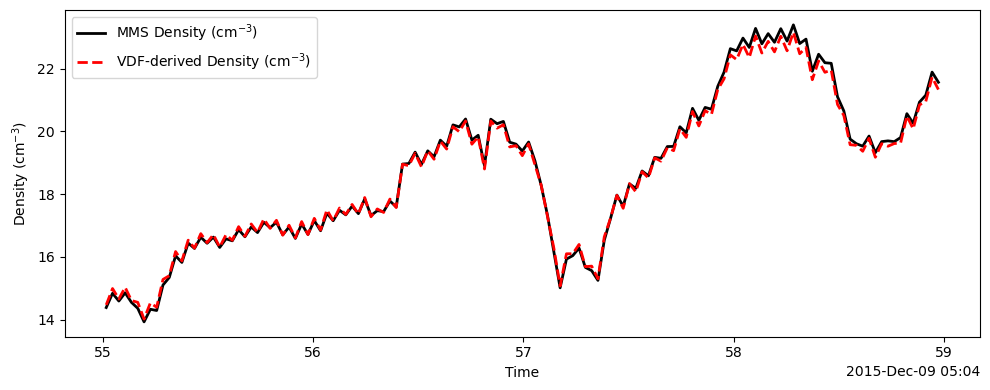

In [25]:
import matplotlib.pyplot as plt
from pyspedas import time_datetime

# Convert your density from m^-3 → cm^-3
ne_vdf_cm = ne_vdf / 1e6
time_dt = time_datetime(time)
plt.figure(figsize=(10,4))

plt.plot(time_dt, ne_mms, label='MMS Density (cm$^{-3}$)', color='k', linewidth=2)
plt.plot(time_dt, ne_vdf_cm, '--', label='VDF-derived Density (cm$^{-3}$)', color='r', linewidth=2)

plt.xlabel('Time')
plt.ylabel('Density (cm$^{-3}$)')
plt.legend()
plt.tight_layout()
plt.show()


In [26]:
ntime = len(time)
ip = np.arange(ntime) % 2
vv_time = vv_coord[:, :, ip]

In [27]:
vv_time.shape, vdf_vol.shape

((3, 16384, 133), (16384, 133))

In [28]:
# numerator: Σ v f over 16384 bins
v_num = np.nansum(vv_time* vdf_vol[None, :, :], axis=1)   # (3, 133)
bulk_ve_gse_vdf = (v_num/ne_vdf[None, :]).T

In [29]:
bulk_ve_gse_vdf.shape

(133, 3)

In [30]:
bulkve = mms.fpi(trange= trange, probe='1', data_rate='brst',level='l2',
        datatype=['des-dist', 'des-moms'], time_clip=True, 
        varnames=['mms1_des_bulkv_gse_brst'], get_support_data=True, no_update=True)

16-Apr-26 17:22:53: Searching for local files...
16-Apr-26 17:22:53: Loading: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-dist/2015/12/09/mms1_fpi_brst_l2_des-dist_20151209050044_v3.3.0.cdf
16-Apr-26 17:22:53: Searching for local files...
16-Apr-26 17:22:53: Loading: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-moms/2015/12/09/mms1_fpi_brst_l2_des-moms_20151209050044_v3.3.0.cdf
16-Apr-26 17:22:53: Loading files for group: probe: 1, drate: brst, level: l2, datatype: des-dist, after sorting and filtering:
16-Apr-26 17:22:53: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-dist/2015/12/09/mms1_fpi_brst_l2_des-dist_20151209050044_v3.3.0.cdf
16-Apr-26 17:22:53: Loading files for group: probe: 1, drate: brst, level: l2, datatype: des-moms, after sorting and filtering:
16-Apr-26 17:22:53: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-moms/2015/12/09/mms1_fpi_brst_l2_des-moms_20151209050044_v3.3.0.cdf
16-Apr-26 17:22:53: wildcard_expand: No match found for *_des_errorf

In [31]:
bulkve

['mms1_des_bulkv_gse_brst']

In [32]:
tplot_rename('mms1_des_bulkv_gse_brst', 'bulk_ve_gse_mms')

In [33]:
_, bulk_ve_gse_mms = get_data('bulk_ve_gse_mms')

In [34]:
bulk_ve_gse_mms.shape

(133, 3)

In [35]:
bulk_ve_gse_vdf[0,:], bulk_ve_gse_mms[0,:]

(array([-140.90668044,   75.64576662,   46.41938298]),
 array([-123.75752,   80.81048,   52.11287], dtype=float32))

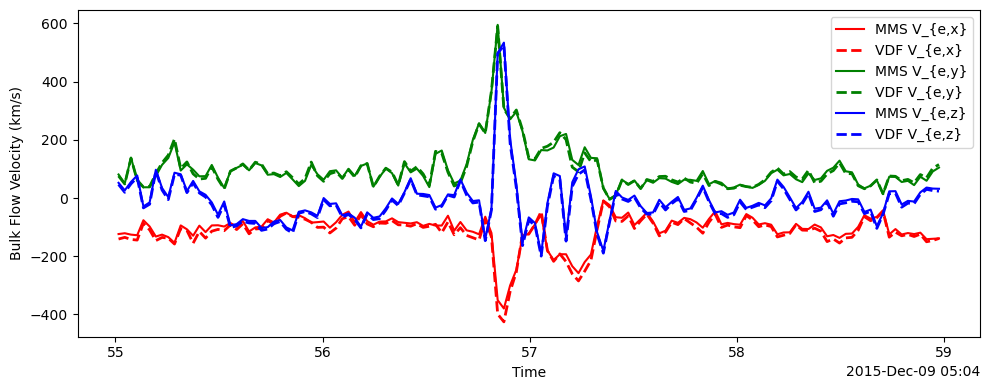

In [36]:
colors = ['r', 'g', 'b']
labels = [r'V_{e,x}', r'V_{e,y}', r'V_{e,z}']

plt.figure(figsize=(10,4))

for i, c in enumerate(colors):
    # MMS solid
    plt.plot(time_dt, bulk_ve_gse_mms[:, i],
             color=c, linewidth=1.5,
             label=f'MMS {labels[i]}')

    # VDF dashed
    plt.plot(time_dt, bulk_ve_gse_vdf[:, i],
             '--', color=c, linewidth=2,
             label=f'VDF {labels[i]}')

plt.xlabel('Time')
plt.ylabel('Bulk Flow Velocity (km/s)')
plt.legend()
plt.tight_layout()
plt.show()


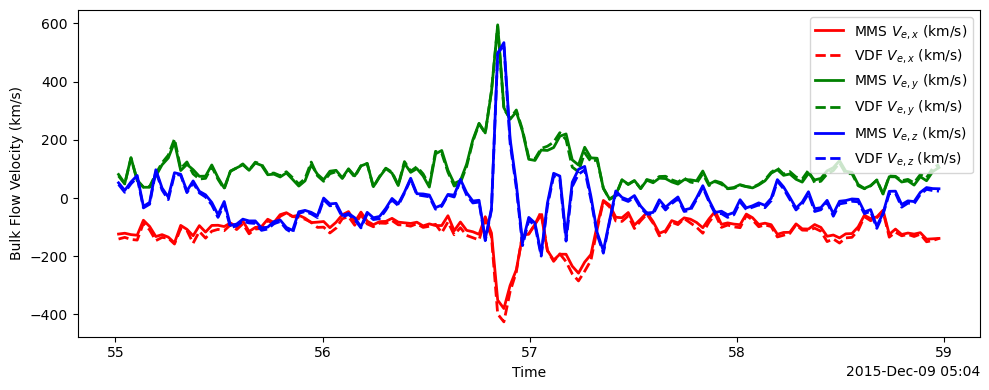

In [37]:
import matplotlib.pyplot as plt
from pyspedas import time_datetime

time_dt = time_datetime(time)
plt.figure(figsize=(10,4))

labels = ['$V_{e,x}$', '$V_{e,y}$', '$V_{e,z}$']
colors = ['r', 'g', 'b']

for i, c in enumerate(colors):
    # MMS solid
    plt.plot(time_dt, bulk_ve_gse_mms[:, i], color = c, 
        label=f'MMS {labels[i]} (km/s)',linewidth=2)
    # VDF dashed
    plt.plot(time_dt, bulk_ve_gse_vdf[:, i], '--', color = c, 
        label=f'VDF {labels[i]} (km/s)', linewidth=2)

plt.xlabel('Time')
plt.ylabel('Bulk Flow Velocity (km/s)')
plt.legend()
plt.tight_layout()
plt.show()


In [38]:
with h5py.File(hfile, "r") as f:
    vmap_fac = f["fac"]["vmap_fac"][:]

In [39]:
vmap_fac

array([[[  13,   13],
        [  13,   13],
        [  13,   13],
        ...,
        [  15,   15],
        [  16,   16],
        [  16,   16]],

       [[  14,   14],
        [  14,   14],
        [  14,   14],
        ...,
        [   1,    2],
        [-999,    0],
        [-999, -999]],

       [[  15,   15],
        [  15,   15],
        [  16,   15],
        ...,
        [-999, -999],
        [-999, -999],
        [-999, -999]]], shape=(3, 16384, 2))

In [40]:
with h5py.File(hfile, "r") as f:
    je_tot_fac = f["fac"]["JE_tot"][:]

In [41]:
je_tot_fac[:, 62]

array([-3.38165843e-10,  2.11620903e-09, -8.98340522e-09])

In [42]:
vdf_vol[:, 62]

array([527.81232201, 251.41426943, 229.40550255, ...,          nan,
                nan,          nan], shape=(16384,))

In [43]:
with h5py.File(hfile, "r") as f:
    bvdf_vol_fac = f["fac"]["bvdf_vol"][:]

In [44]:
bvdf_vol_fac.shape

(28, 28, 28, 133)

In [45]:
bvdf_vol_fac[:, :, :, 62]

array([[[ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

       [[ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

       [[nan,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

       ...,

       [[nan,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.

In [46]:
idx = np.argwhere(~np.isnan(bvdf_vol_fac[..., 62]) & (bvdf_vol_fac[..., 62] != 0))
vals = bvdf_vol_fac[..., 62][~np.isnan(bvdf_vol_fac[..., 62]) & (bvdf_vol_fac[..., 62] != 0)]

In [47]:
vals

array([144.25395993,  54.75477005, 183.81366369, ..., 215.09463718,
        70.10905256,  74.29131717], shape=(3495,))

In [48]:
with h5py.File(hfile, "r") as f:
    evec_lor_fac = f["fac"]["evec_lor_fac"][:]

In [54]:
evec_lor_fac[62, 0], evec_lor_fac[62, 1], evec_lor_fac[62, 2]

(np.float64(-0.4348161968453283),
 np.float64(1.9242708465538607),
 np.float64(-5.611021206511331))

In [55]:
with h5py.File(hfile, "r") as f:
    Cprime_vol_fac = f["fac"]["Cprime_vol"][:]

In [58]:
Cprime_vol_fac[2, :, 62]

array([8.08685436e-13, 4.54686481e-13, 4.84104453e-13, ...,
                  nan,            nan,            nan], shape=(16384,))

In [61]:
idx = np.argwhere(~np.isnan(Cprime_vol_fac[2, :, 62]) & (Cprime_vol_fac[2, :, 62] != 0))
vals = Cprime_vol_fac[2, :, 62][~np.isnan(Cprime_vol_fac[2, :, 62]) & (Cprime_vol_fac[2, :, 62] != 0)]

In [62]:
vals

array([ 8.08685436e-13,  4.54686481e-13,  4.84104453e-13, ...,
       -8.85915483e-13, -7.04695355e-13, -2.12269307e-13], shape=(8530,))

In [63]:
np.nansum(Cprime_vol_fac[2, :, 62])

np.float64(-8.904045733362543e-09)

In [65]:
from scipy.constants import elementary_charge as q_e
CHARGE = {'e': -q_e, 'ion': +q_e}
q = CHARGE[species]

In [ ]:
from 